# 03 — RQ2 distributed join & scaling

Speedup S(n) and efficiency E(n), wall-clock vs workers with single-node baselines & crossover, execution-phase time + shuffle bytes, cost-time Pareto, raw Spark metrics (appendix), and the distributed descriptive-statistics table.

Asymmetries from `benchmarks.yml` (real): broadcast ran small/medium/large; **partitioned** ran small only (medium/large = executor OOM); single-node duckdb/postgis ran small/medium (large = timeout / OOM). Failed cells render as `failed`, never zero.

In [1]:
import os, shutil
from pathlib import Path
if Path.cwd().name == "notebooks":
    os.chdir("..")
from src.plotting.style import StyleConfig
from src.plotting.charts import plot_databricks_metrics
from src.analysis.tables import build_cost_summary
from src.analysis import thesis_compute as tc
from src.analysis import thesis_tables as tt
from src.plotting import thesis_figures as tf

style = StyleConfig(); style.apply_rcparams()
CACHE = os.environ.get("DOPPA_CACHE", "cache/bench-cache.duckdb")
RUN_ID = "2026-05-26-OY0CN3"
FIG = Path("figures"); TAB = Path("tables")
DBR = ["executor_input_bytes_read", "executor_run_time_ms", "shuffle_read_bytes",
       "shuffle_write_bytes", "driver_collection_time_ms"]

experiments, samples_df, metadata_df, costs_df, successful = tc.load_all(
    CACHE, "../doppa/benchmarks.yml", RUN_ID)
cost_summary = build_cost_summary(costs_df)
scaling = tc.rq2_scaling(successful)
single = tc.rq2_single_node(successful)
failed = tc.rq2_failed(successful, experiments)
phase = tc.rq2_phase(successful)
pareto = tc.rq2_pareto(successful, cost_summary)
print("scaling rows:", len(scaling), "| phase rows:", len(phase))

scaling rows: 20 | phase rows: 15


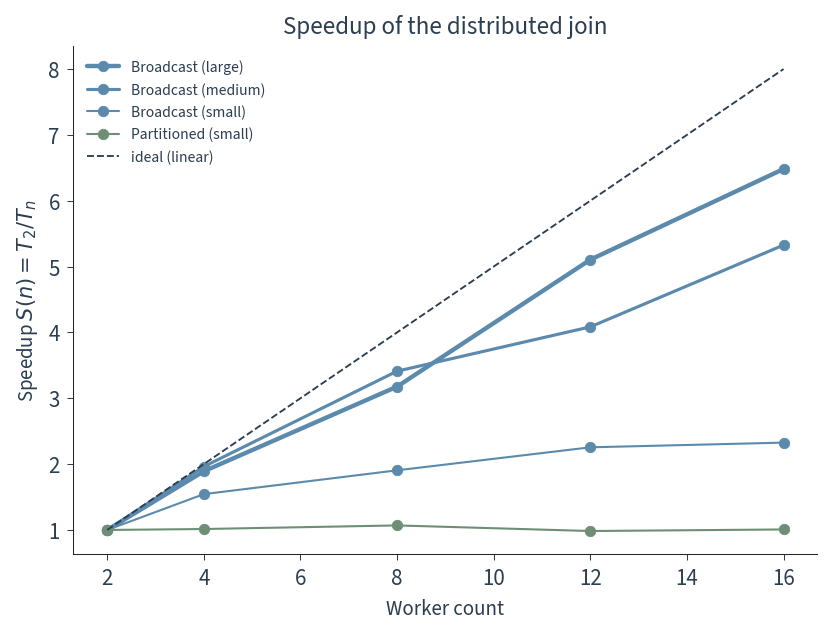

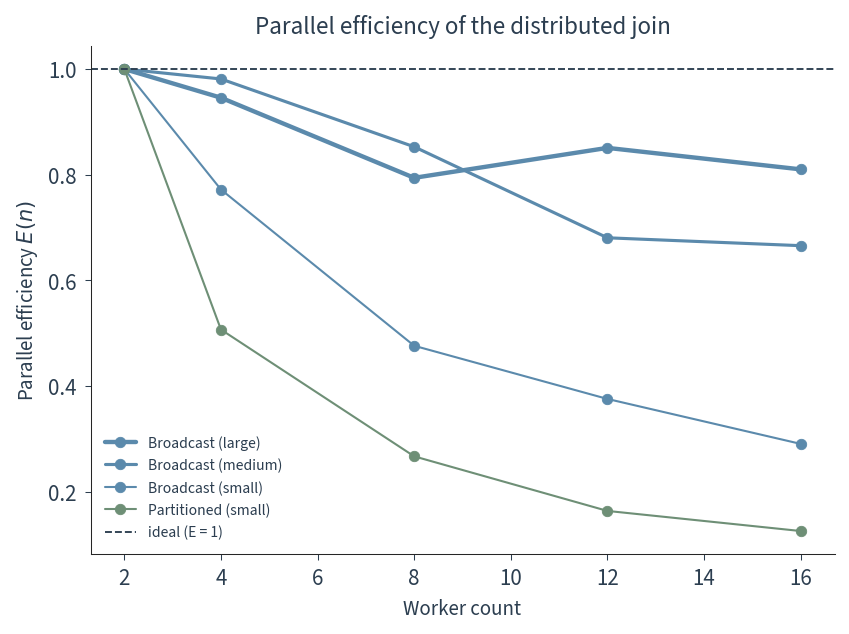

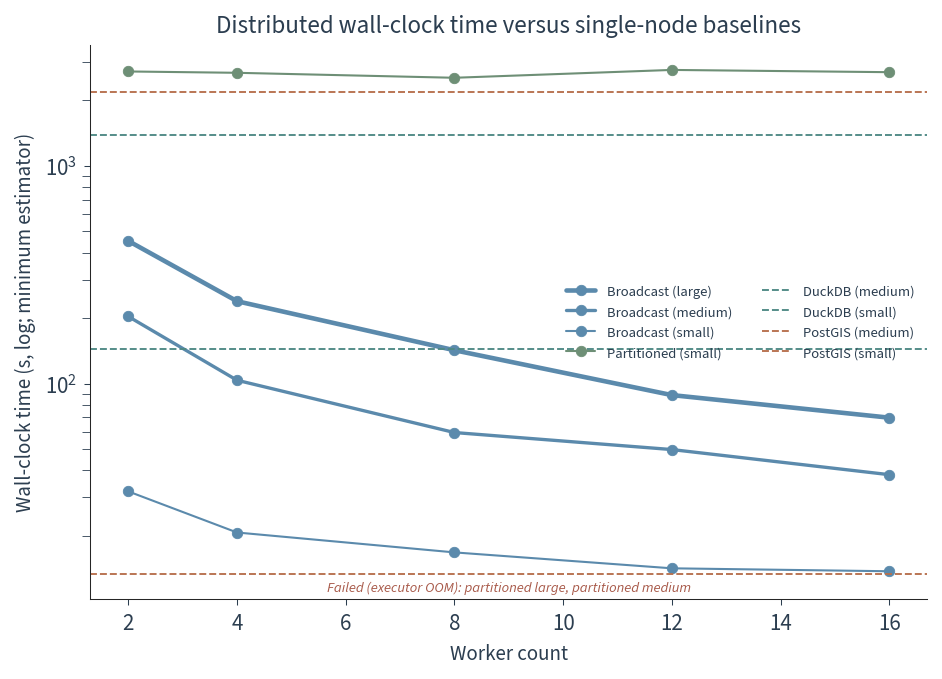

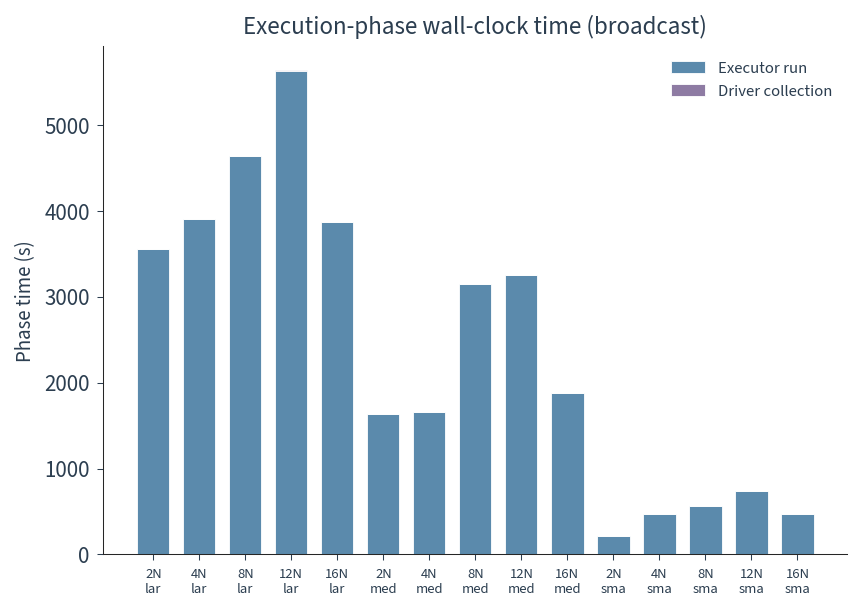

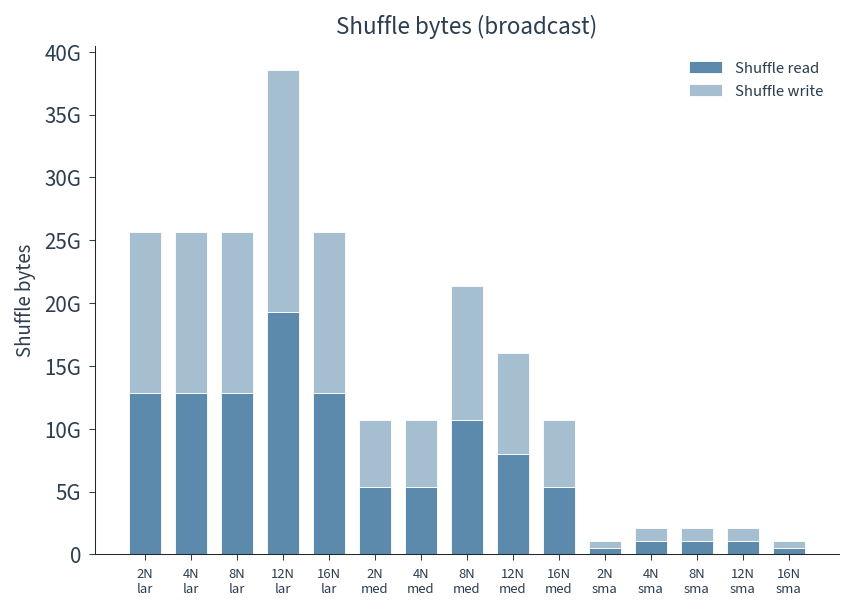

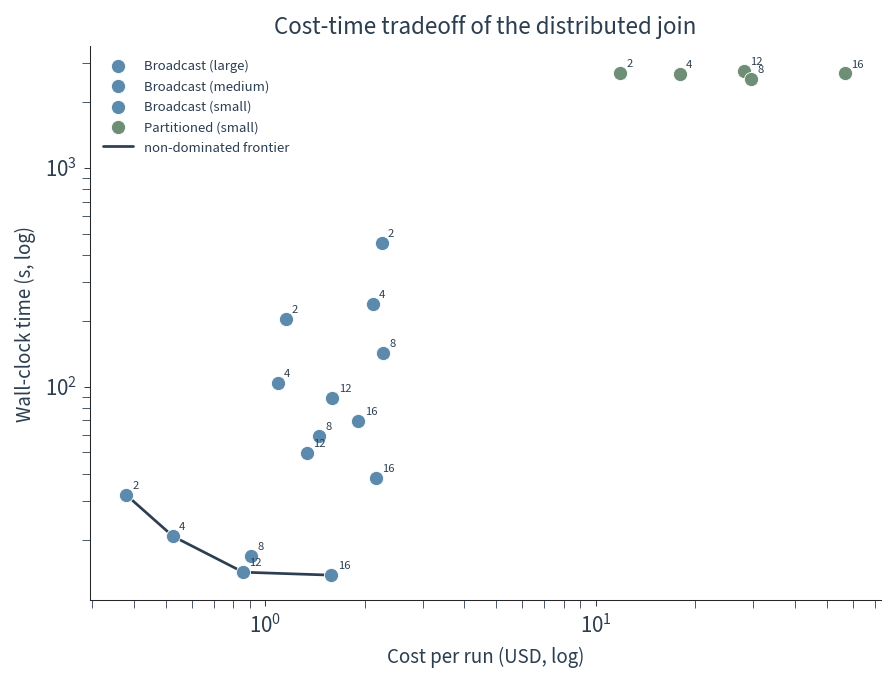

PosixPath('figures/06-distributed-cost-time-pareto.png')

In [2]:
tf.fig_speedup(scaling, style, FIG / "06-distributed-speedup.png")
tf.fig_efficiency(scaling, style, FIG / "06-distributed-efficiency.png")
tf.fig_wall_clock_vs_workers(scaling, single, failed, style, FIG / "06-distributed-wall-clock-vs-workers.png")
tf.fig_phase_time(phase, style, FIG / "06-distributed-phase-time.png")
tf.fig_shuffle_bytes(phase, style, FIG / "06-distributed-shuffle-bytes.png")
tf.fig_cost_pareto(pareto, style, FIG / "06-distributed-cost-time-pareto.png")

In [ ]:
# --- New RQ2 + appendix figures (thesis_figures.fig_*) ---
tf.fig_distributed_strategy_contrast(successful, cost_summary, style, FIG / "06-distributed-strategy-contrast.png")
tf.fig_distributed_client_boundary(successful, style, FIG / "06-distributed-client-boundary.png")
tf.fig_spark_stage_profile(successful, style, FIG / "09-spark-stage-profile.png")

## Raw Spark-internal metrics → `09-spark-metrics.png` (reuses `plot_databricks_metrics`)

In [ ]:
nat = successful[successful["workload_type"] == "national-scale-spatial-join"]
plot_databricks_metrics(nat, DBR, style, FIG)
shutil.copy(FIG / "databricks_metrics.png", FIG / "09-spark-metrics.png")
shutil.copy(FIG / "databricks_metrics.pdf", FIG / "09-spark-metrics.pdf")

## Distributed descriptive-statistics table → `06-distributed-descriptive-stats.tex` (`tab:distributed-join-descriptive-statistics`)

In [4]:
tt.emit_distributed_descriptive(successful, metadata_df, cost_summary, experiments,
                                TAB / "06-distributed-descriptive-stats.tex")

,dataset_size,strategy,workers,achieved_n,min_s,ci_halfwidth_s,cost_usd,status
0,small,broadcast,2,9,31.980829,0.928328,0.379964,ran
1,small,broadcast,4,9,20.711961,0.972723,0.525746,ran
2,small,broadcast,8,9,16.782088,0.496018,0.906907,ran
3,small,broadcast,12,6,14.182210,0.732205,0.858552,ran
4,small,broadcast,16,9,13.747047,0.486067,1.587522,ran
5,medium,broadcast,2,9,203.364927,1.010156,1.154565,ran
6,medium,broadcast,4,9,103.629750,5.103617,1.092868,ran
7,medium,broadcast,8,9,59.612629,1.956483,1.459923,ran
8,medium,broadcast,12,6,49.792548,2.140032,1.339569,ran
9,medium,broadcast,16,9,38.180573,0.696998,2.163346,ran
